# Assignment 6: Introduction to CUDA

> **Important:** Before running, go to `Runtime → Change runtime type → Hardware accelerator → T4 GPU`

---

## Setup: Install PyCUDA

In [ ]:
!pip install pycuda -q
import pycuda.driver as cuda
import pycuda.autoinit
from pycuda.compiler import SourceModule
import numpy as np
import time
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
print('PyCUDA ready!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 35.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.8/98.8 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 11.1 MB/s eta 0:00:00
PyCUDA ready!


---
## Part A: Device Query

Query GPU properties and answer the assignment questions.

In [ ]:
# ── Device Query ──────────────────────────────────────────────────────────────
dev = cuda.Device(0)
attr = dev.get_attributes()

print('=' * 60)
print('           GPU DEVICE QUERY RESULTS')
print('=' * 60)
print(f'  Device Name                  : {dev.name()}')
print(f'  Compute Capability           : {dev.compute_capability()[0]}.{dev.compute_capability()[1]}')
print(f'  Total Global Memory          : {dev.total_memory() / 1024**3:.2f} GB')
print(f'  Shared Memory per Block      : {attr[cuda.device_attribute.MAX_SHARED_MEMORY_PER_BLOCK] / 1024:.0f} KB')
print(f'  Constant Memory              : {attr[cuda.device_attribute.TOTAL_CONSTANT_MEMORY] / 1024:.0f} KB')
print(f'  Warp Size                    : {attr[cuda.device_attribute.WARP_SIZE]}')
print(f'  Max Threads per Block        : {attr[cuda.device_attribute.MAX_THREADS_PER_BLOCK]}')
print(f'  Max Block Dim X              : {attr[cuda.device_attribute.MAX_BLOCK_DIM_X]}')
print(f'  Max Block Dim Y              : {attr[cuda.device_attribute.MAX_BLOCK_DIM_Y]}')
print(f'  Max Block Dim Z              : {attr[cuda.device_attribute.MAX_BLOCK_DIM_Z]}')
print(f'  Max Grid Dim X               : {attr[cuda.device_attribute.MAX_GRID_DIM_X]}')
print(f'  Max Grid Dim Y               : {attr[cuda.device_attribute.MAX_GRID_DIM_Y]}')
print(f'  Max Grid Dim Z               : {attr[cuda.device_attribute.MAX_GRID_DIM_Z]}')
print(f'  Multiprocessors (SMs)        : {attr[cuda.device_attribute.MULTIPROCESSOR_COUNT]}')
print(f'  Clock Rate                   : {attr[cuda.device_attribute.CLOCK_RATE] / 1e6:.2f} GHz')
print(f'  Memory Clock Rate            : {attr[cuda.device_attribute.MEMORY_CLOCK_RATE] / 1e6:.2f} GHz')
print(f'  L2 Cache Size                : {attr[cuda.device_attribute.L2_CACHE_SIZE] / 1024:.0f} KB')
print(f'  Max Threads per SM           : {attr[cuda.device_attribute.MAX_THREADS_PER_MULTIPROCESSOR]}')
# Double precision check
dp_perf = attr.get(cuda.device_attribute.SINGLE_TO_DOUBLE_PRECISION_PERF_RATIO, None)
cc = dev.compute_capability()
dp_supported = cc[0] > 1 or (cc[0] == 1 and cc[1] >= 3)
print(f'  Double Precision Supported   : {"Yes" if dp_supported else "No"}')
print('=' * 60)

           GPU DEVICE QUERY RESULTS
  Device Name                  : Tesla T4
  Compute Capability           : 7.5
  Total Global Memory          : 14.56 GB
  Shared Memory per Block      : 48 KB
  Constant Memory              : 64 KB
  Warp Size                    : 32
  Max Threads per Block        : 1024
  Max Block Dim X              : 1024
  Max Block Dim Y              : 1024
  Max Block Dim Z              : 64
  Max Grid Dim X               : 2147483647
  Max Grid Dim Y               : 65535
  Max Grid Dim Z               : 65535
  Multiprocessors (SMs)        : 40
  Clock Rate                   : 1.59 GHz
  Memory Clock Rate            : 5.00 GHz
  L2 Cache Size                : 4096 KB
  Max Threads per SM           : 1024
  Double Precision Supported   : Yes


In [ ]:
# ── Answers to Part A Questions ───────────────────────────────────────────────
attr = dev.get_attributes()
cc = dev.compute_capability()
max_grid_x  = attr[cuda.device_attribute.MAX_GRID_DIM_X]
max_block_x = attr[cuda.device_attribute.MAX_BLOCK_DIM_X]
shared_mem  = attr[cuda.device_attribute.MAX_SHARED_MEMORY_PER_BLOCK]
const_mem   = attr[cuda.device_attribute.TOTAL_CONSTANT_MEMORY]
warp_size   = attr[cuda.device_attribute.WARP_SIZE]
global_mem  = dev.total_memory()

print('\n========== PART A: ANSWERS TO QUESTIONS ==========')

print(f"""
Q1. Architecture and Compute Capability:
    Device  : {dev.name()}
    Compute : {cc[0]}.{cc[1]}
    (Compute 7.5 → Turing architecture for T4)

Q2. Maximum Block Dimensions:
    X = {attr[cuda.device_attribute.MAX_BLOCK_DIM_X]}
    Y = {attr[cuda.device_attribute.MAX_BLOCK_DIM_Y]}
    Z = {attr[cuda.device_attribute.MAX_BLOCK_DIM_Z]}

Q3. Maximum Threads (1D grid, grid=65535, block=512):
    Max threads = 65535 × 512 = {65535 * 512:,}

Q4. When NOT to launch maximum threads:
    - When the problem size is small (wasted idle threads)
    - When each thread uses lots of registers/shared memory
      (limits occupancy via register pressure)
    - When synchronisation overhead becomes dominant
    - When debugging (smaller grids are easier to trace)

Q5. What can limit maximum threads:
    - Available GPU global memory
    - Register file size per SM
    - Shared memory per SM
    - Hardware limits (max threads per block / per SM)
    - OS/driver limits on kernel launch

Q6. Shared Memory:
    Shared memory is a fast, programmer-managed scratchpad
    on each SM, shared by all threads in a block.
    Per-block shared memory on this GPU: {shared_mem // 1024} KB

Q7. Global Memory:
    Global memory is the main DRAM on the GPU card,
    accessible by all threads but with high latency.
    Total global memory: {global_mem / 1024**3:.2f} GB

Q8. Constant Memory:
    Constant memory is a read-only cache optimised for
    broadcast reads (all threads reading the same address).
    Constant memory: {const_mem // 1024} KB

Q9. Warp Size:
    A warp is the unit of thread scheduling on a GPU.
    All threads in a warp execute the same instruction
    simultaneously (SIMT). Divergence causes serialisation.
    Warp size: {warp_size} threads

Q10. Double Precision Support:
    Supported: {"Yes" if dp_supported else "No"}
    (Compute capability ≥ 1.3 required; this GPU is {cc[0]}.{cc[1]})
""")


========== PART A: ANSWERS TO QUESTIONS ==========

Q1. Architecture and Compute Capability:
    Device  : Tesla T4
    Compute : 7.5
    (Compute 7.5 → Turing architecture for T4)

Q2. Maximum Block Dimensions:
    X = 1024
    Y = 1024
    Z = 64

Q3. Maximum Threads (1D grid, grid=65535, block=512):
    Max threads = 65535 × 512 = 33,553,920

Q4. When NOT to launch maximum threads:
    - When the problem size is small (wasted idle threads)
    - When each thread uses lots of registers/shared memory
      (limits occupancy via register pressure)
    - When synchronisation overhead becomes dominant
    - When debugging (smaller grids are easier to trace)

Q5. What can limit maximum threads:
    - Available GPU global memory
    - Register file size per SM
    - Shared memory per SM
    - Hardware limits (max threads per block / per SM)
    - OS/driver limits on kernel launch

Q6. Shared Memory:
    Shared memory is a fast, programmer-managed scratchpad
    on each SM, shared by all t

---
## Part B: Array Sum with CUDA

Parallel reduction to sum all elements of a float array.

In [ ]:
# ── CUDA Kernel: Parallel Reduction Sum ───────────────────────────────────────
sum_kernel_code = """
#include <stdio.h>

// Each block reduces its chunk into one partial sum using shared memory.
__global__ void reduce_sum(float *input, float *output, int n) {
    extern __shared__ float sdata[];   // dynamic shared memory

    unsigned int tid = threadIdx.x;
    unsigned int idx = blockIdx.x * blockDim.x * 2 + threadIdx.x;

    // Load two elements per thread (first level of reduction during load)
    float val = 0.0f;
    if (idx < n)             val  = input[idx];
    if (idx + blockDim.x < n) val += input[idx + blockDim.x];
    sdata[tid] = val;
    __syncthreads();

    // Tree reduction within shared memory
    for (unsigned int s = blockDim.x / 2; s > 0; s >>= 1) {
        if (tid < s)
            sdata[tid] += sdata[tid + s];
        __syncthreads();
    }

    // Thread 0 writes block result to global output
    if (tid == 0)
        output[blockIdx.x] = sdata[0];
}
"""

mod_sum   = SourceModule(sum_kernel_code)
reduce_fn = mod_sum.get_function('reduce_sum')
print('Sum kernel compiled successfully!')

Sum kernel compiled successfully!


In [ ]:
def cuda_array_sum(h_array, threads_per_block=256):
    """
    Computes sum of h_array on GPU using parallel reduction.
    Returns (gpu_sum, elapsed_ms)
    """
    n = len(h_array)
    h_input = h_array.astype(np.float32)

    # ── 1. Allocate device memory ─────────────────────────────────────────
    d_input  = cuda.mem_alloc(h_input.nbytes)
    n_blocks = (n + threads_per_block * 2 - 1) // (threads_per_block * 2)
    d_output = cuda.mem_alloc(n_blocks * np.dtype(np.float32).itemsize)

    # ── 2. Copy host → device ─────────────────────────────────────────────
    start = cuda.Event()
    end   = cuda.Event()
    start.record()

    cuda.memcpy_htod(d_input, h_input)

    # ── 3 & 4. Launch kernel(s) until fully reduced ───────────────────────
    shared_mem_bytes = threads_per_block * np.dtype(np.float32).itemsize
    current_input  = d_input
    current_n      = n
    current_blocks = n_blocks

    while current_n > 1:
        current_blocks = (current_n + threads_per_block * 2 - 1) // (threads_per_block * 2)
        current_output = cuda.mem_alloc(current_blocks * np.dtype(np.float32).itemsize)
        reduce_fn(
            current_input, current_output, np.int32(current_n),
            block=(threads_per_block, 1, 1),
            grid=(current_blocks, 1),
            shared=shared_mem_bytes
        )
        current_input = current_output
        current_n     = current_blocks

    # ── 5. Copy result device → host ──────────────────────────────────────
    h_result = np.zeros(1, dtype=np.float32)
    cuda.memcpy_dtoh(h_result, current_input)

    end.record()
    end.synchronize()
    elapsed_ms = start.time_till(end)

    # ── 6. Free device memory ─────────────────────────────────────────────
    d_input.free()
    current_output.free()

    return float(h_result[0]), elapsed_ms


# ── Correctness Test ──────────────────────────────────────────────────────────
print('=== Part B: Array Sum Correctness Test ===')
N = 1 << 20   # 1M elements
h_arr = np.random.uniform(0, 1, N).astype(np.float32)

gpu_sum, ms = cuda_array_sum(h_arr)
cpu_sum = float(np.sum(h_arr.astype(np.float64)))   # higher precision ref

print(f'  Array size : {N:,} elements')
print(f'  GPU sum    : {gpu_sum:.4f}')
print(f'  CPU sum    : {cpu_sum:.4f}')
print(f'  Difference : {abs(gpu_sum - cpu_sum):.4f}  (float32 rounding expected)')
print(f'  GPU time   : {ms:.3f} ms')

=== Part B: Array Sum Correctness Test ===
  Array size : 1,048,576 elements
  GPU sum    : 524333.3125
  CPU sum    : 524333.3257
  Difference : 0.0132  (float32 rounding expected)
  GPU time   : 2.517 ms



=== Part B: Performance vs Array Size ===
  N=   16,384 | GPU   1.779 ms | CPU   0.052 ms | Speedup 0.03x
  N=   65,536 | GPU   0.178 ms | CPU   0.065 ms | Speedup 0.37x
  N=  262,144 | GPU   0.356 ms | CPU   0.154 ms | Speedup 0.43x
  N=1,048,576 | GPU   1.098 ms | CPU   0.544 ms | Speedup 0.50x
  N=4,194,304 | GPU   4.107 ms | CPU   1.498 ms | Speedup 0.36x
  N=16,777,216 | GPU  16.398 ms | CPU   9.400 ms | Speedup 0.57x


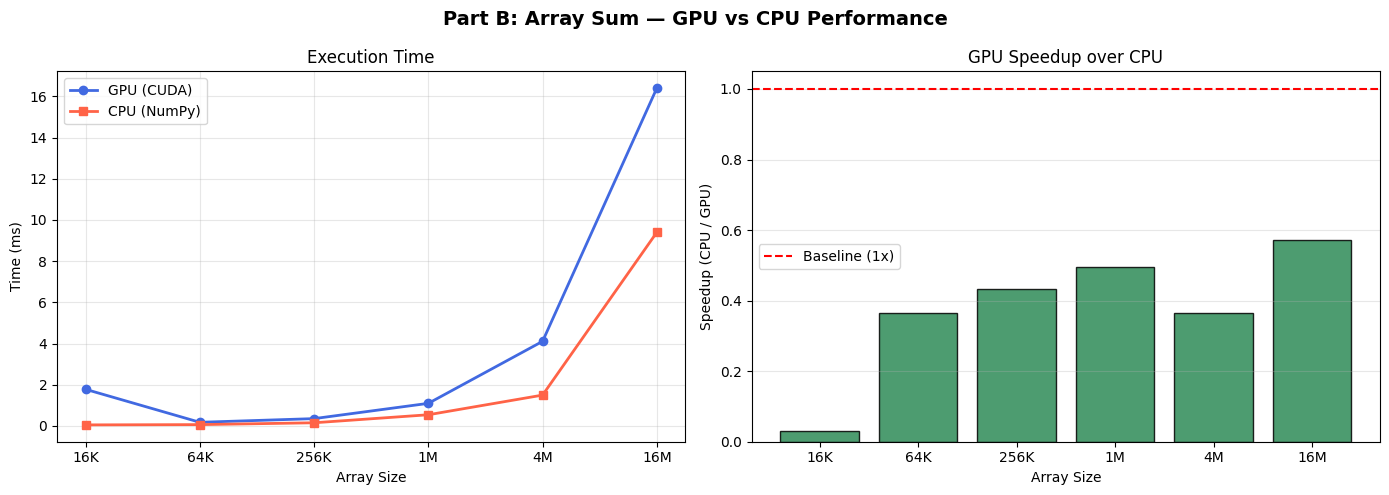

Plot saved: partB_performance.png


In [ ]:
# ── Part B: Performance Analysis ──────────────────────────────────────────────
print('\n=== Part B: Performance vs Array Size ===')
sizes     = [1<<14, 1<<16, 1<<18, 1<<20, 1<<22, 1<<24]
gpu_times = []
cpu_times = []
speedups  = []

for n in sizes:
    arr = np.random.uniform(0, 1, n).astype(np.float32)

    # GPU
    _, gms = cuda_array_sum(arr)
    # Warm up
    _, gms = cuda_array_sum(arr)

    # CPU
    t0 = time.perf_counter()
    _ = np.sum(arr)
    cpu_ms = (time.perf_counter() - t0) * 1000

    gpu_times.append(gms)
    cpu_times.append(cpu_ms)
    speedups.append(cpu_ms / gms)
    print(f'  N={n:>9,} | GPU {gms:7.3f} ms | CPU {cpu_ms:7.3f} ms | Speedup {cpu_ms/gms:.2f}x')

# ── Plot ──────────────────────────────────────────────────────────────────────
labels = [f'{n//1024}K' if n < 1<<20 else f'{n//1048576}M' for n in sizes]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Part B: Array Sum — GPU vs CPU Performance', fontsize=14, fontweight='bold')

axes[0].plot(labels, gpu_times, 'o-', color='royalblue',  label='GPU (CUDA)', linewidth=2)
axes[0].plot(labels, cpu_times, 's-', color='tomato',     label='CPU (NumPy)', linewidth=2)
axes[0].set_xlabel('Array Size')
axes[0].set_ylabel('Time (ms)')
axes[0].set_title('Execution Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(labels, speedups, color='seagreen', edgecolor='black', alpha=0.85)
axes[1].axhline(y=1, color='red', linestyle='--', label='Baseline (1x)')
axes[1].set_xlabel('Array Size')
axes[1].set_ylabel('Speedup (CPU / GPU)')
axes[1].set_title('GPU Speedup over CPU')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('partB_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: partB_performance.png')


=== Part B: Effect of Block Size on Performance ===
  Block size=  32 | 4.114 ms
  Block size=  64 | 3.952 ms
  Block size= 128 | 3.949 ms
  Block size= 256 | 3.904 ms
  Block size= 512 | 3.965 ms


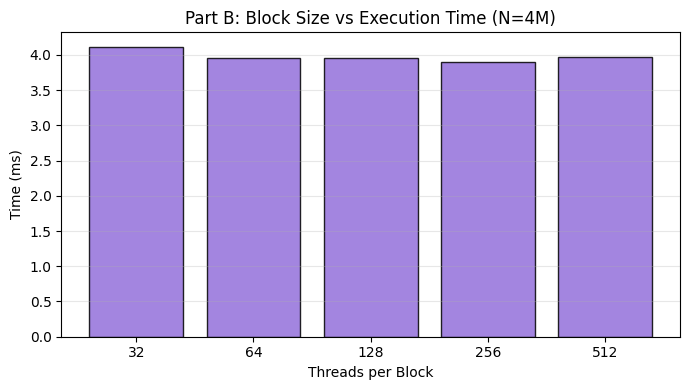

Plot saved: partB_blocksize.png


In [ ]:
# ── Part B: Block Size Sweep ───────────────────────────────────────────────────
print('\n=== Part B: Effect of Block Size on Performance ===')
N_fixed      = 1 << 22
arr_fixed    = np.random.uniform(0, 1, N_fixed).astype(np.float32)
block_sizes  = [32, 64, 128, 256, 512]
blk_times    = []

for bs in block_sizes:
    _, _ = cuda_array_sum(arr_fixed, bs)   # warm-up
    _, ms = cuda_array_sum(arr_fixed, bs)
    blk_times.append(ms)
    print(f'  Block size={bs:>4} | {ms:.3f} ms')

plt.figure(figsize=(7, 4))
plt.bar([str(b) for b in block_sizes], blk_times, color='mediumpurple', edgecolor='black', alpha=0.85)
plt.xlabel('Threads per Block')
plt.ylabel('Time (ms)')
plt.title(f'Part B: Block Size vs Execution Time (N={N_fixed//1048576}M)')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('partB_blocksize.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: partB_blocksize.png')

---
## Part C: Matrix Addition with CUDA

In [ ]:
# ── CUDA Kernel: Matrix Addition ──────────────────────────────────────────────
mat_add_code = """
__global__ void matrix_add(int *A, int *B, int *C, int rows, int cols) {
    // Map 2D thread/block index to flat matrix index
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    int row = blockIdx.y * blockDim.y + threadIdx.y;

    if (row < rows && col < cols) {
        int idx = row * cols + col;
        C[idx] = A[idx] + B[idx];   // 1 FLOP, 2 reads, 1 write
    }
}
"""

mod_mat  = SourceModule(mat_add_code)
mat_add  = mod_mat.get_function('matrix_add')
print('Matrix addition kernel compiled!')

Matrix addition kernel compiled!


In [ ]:
def cuda_matrix_add(A, B, block_dim=16):
    """
    GPU matrix addition: C = A + B
    Returns (C, elapsed_ms)
    """
    assert A.shape == B.shape
    rows, cols = A.shape
    A32 = A.astype(np.int32)
    B32 = B.astype(np.int32)
    C32 = np.zeros_like(A32)

    # ── 1. Allocate device memory ─────────────────────────────────────────
    d_A = cuda.mem_alloc(A32.nbytes)
    d_B = cuda.mem_alloc(B32.nbytes)
    d_C = cuda.mem_alloc(C32.nbytes)

    # ── 2. Copy host → device ─────────────────────────────────────────────
    start = cuda.Event(); end = cuda.Event()
    start.record()

    cuda.memcpy_htod(d_A, A32)
    cuda.memcpy_htod(d_B, B32)

    # ── 3. Grid / Block dimensions ────────────────────────────────────────
    block  = (block_dim, block_dim, 1)
    grid_x = (cols + block_dim - 1) // block_dim
    grid_y = (rows + block_dim - 1) // block_dim
    grid   = (grid_x, grid_y, 1)

    # ── 4. Launch kernel ──────────────────────────────────────────────────
    mat_add(d_A, d_B, d_C, np.int32(rows), np.int32(cols),
            block=block, grid=grid)

    # ── 5. Copy result device → host ──────────────────────────────────────
    cuda.memcpy_dtoh(C32, d_C)

    end.record(); end.synchronize()
    elapsed_ms = start.time_till(end)

    # ── 6. Free device memory ─────────────────────────────────────────────
    d_A.free(); d_B.free(); d_C.free()

    return C32, elapsed_ms


# ── Correctness Test ──────────────────────────────────────────────────────────
print('=== Part C: Matrix Addition Correctness Test ===')
N = 512
A = np.random.randint(0, 100, (N, N), dtype=np.int32)
B = np.random.randint(0, 100, (N, N), dtype=np.int32)

C_gpu, ms = cuda_matrix_add(A, B)
C_cpu     = A + B

print(f'  Matrix size : {N}×{N}')
print(f'  Match       : {np.array_equal(C_gpu, C_cpu)}')
print(f'  GPU time    : {ms:.3f} ms')

=== Part C: Matrix Addition Correctness Test ===
  Matrix size : 512×512
  Match       : True
  GPU time    : 1.026 ms


In [ ]:
# ── Part C: Analysis Questions ────────────────────────────────────────────────
N_example = 1024
total_elements = N_example * N_example

print('=== Part C: Answers to Questions ===')
print(f"""
For an {N_example}×{N_example} matrix:

Q1. Floating-point operations in kernel:
    Each thread performs 1 addition → C[idx] = A[idx] + B[idx]
    Total FLOPs = rows × cols = {N_example} × {N_example} = {total_elements:,}

Q2. Global memory READS:
    Each thread reads A[idx] and B[idx] → 2 reads per thread
    Total reads = 2 × {total_elements:,} = {2*total_elements:,}
    (= {2*total_elements*4/1024**2:.1f} MB for int32)

Q3. Global memory WRITES:
    Each thread writes C[idx] → 1 write per thread
    Total writes = {total_elements:,}
    (= {total_elements*4/1024**2:.1f} MB for int32)

Arithmetic Intensity = {N_example}²  FLOPs / (3 × {N_example}² × 4 bytes)
                     = 1 / 12  ≈ 0.083 FLOPs/byte  → memory-bound kernel
""")

=== Part C: Answers to Questions ===

For an 1024×1024 matrix:

Q1. Floating-point operations in kernel:
    Each thread performs 1 addition → C[idx] = A[idx] + B[idx]
    Total FLOPs = rows × cols = 1024 × 1024 = 1,048,576

Q2. Global memory READS:
    Each thread reads A[idx] and B[idx] → 2 reads per thread
    Total reads = 2 × 1,048,576 = 2,097,152
    (= 8.0 MB for int32)

Q3. Global memory WRITES:
    Each thread writes C[idx] → 1 write per thread
    Total writes = 1,048,576
    (= 4.0 MB for int32)

Arithmetic Intensity = 1024²  FLOPs / (3 × 1024² × 4 bytes)
                     = 1 / 12  ≈ 0.083 FLOPs/byte  → memory-bound kernel




=== Part C: Performance vs Matrix Size ===
    128×128   | GPU    0.174 ms | CPU    0.051 ms | BW 1.1 GB/s | Speedup 0.29x
    256×256   | GPU    0.314 ms | CPU    0.045 ms | BW 2.5 GB/s | Speedup 0.14x
    512×512   | GPU    0.989 ms | CPU    0.141 ms | BW 3.2 GB/s | Speedup 0.14x
   1024×1024  | GPU    3.129 ms | CPU    1.222 ms | BW 4.0 GB/s | Speedup 0.39x
   2048×2048  | GPU   11.226 ms | CPU    5.696 ms | BW 4.5 GB/s | Speedup 0.51x
   4096×4096  | GPU   44.891 ms | CPU   28.053 ms | BW 4.5 GB/s | Speedup 0.62x


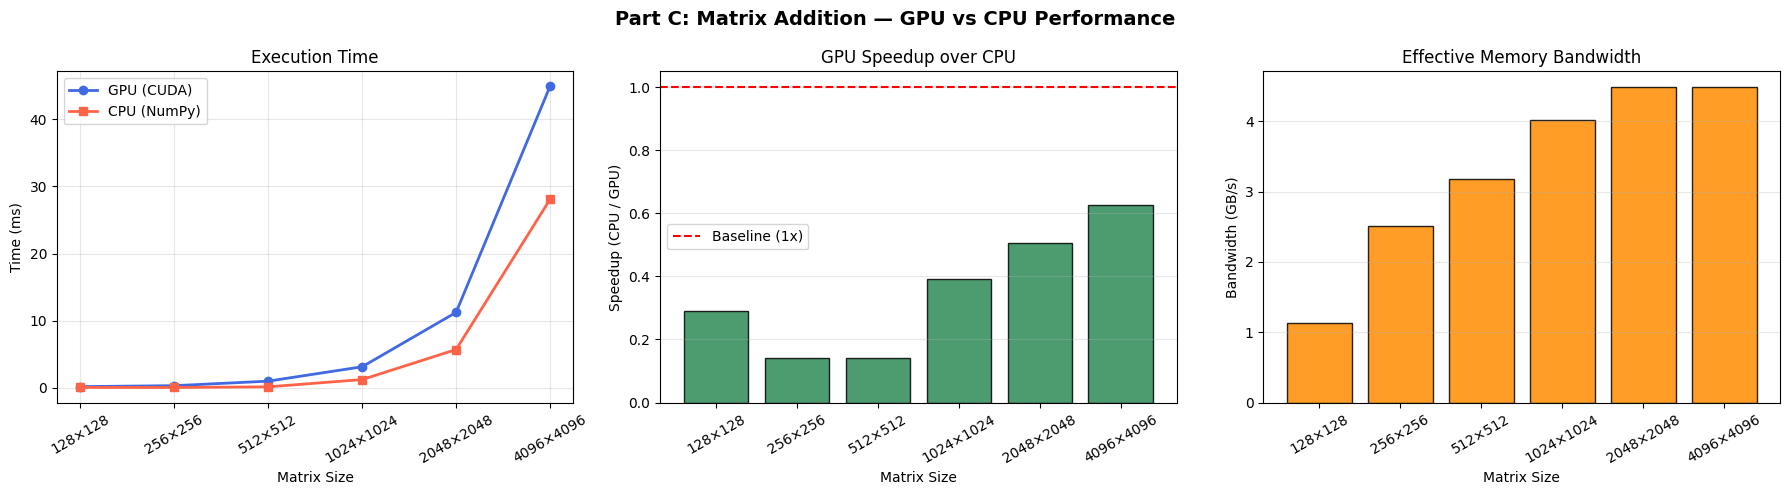

Plot saved: partC_performance.png


In [ ]:
# ── Part C: Performance Analysis vs Matrix Size ────────────────────────────────
print('\n=== Part C: Performance vs Matrix Size ===')
mat_sizes  = [128, 256, 512, 1024, 2048, 4096]
gpu_times_mat = []
cpu_times_mat = []
flops_list    = []
bw_list       = []

for n in mat_sizes:
    A = np.random.randint(0, 100, (n, n), dtype=np.int32)
    B = np.random.randint(0, 100, (n, n), dtype=np.int32)

    # GPU warm-up then measure
    _, _ = cuda_matrix_add(A, B)
    _, gms = cuda_matrix_add(A, B)

    # CPU
    t0 = time.perf_counter()
    _ = A + B
    cpu_ms = (time.perf_counter() - t0) * 1000

    gpu_times_mat.append(gms)
    cpu_times_mat.append(cpu_ms)

    # Effective bandwidth (GB/s): 3 arrays × n² × 4 bytes
    bytes_moved = 3 * n * n * 4
    bw = bytes_moved / (gms * 1e-3) / 1e9
    bw_list.append(bw)

    print(f'  {n:>5}×{n:<5} | GPU {gms:8.3f} ms | CPU {cpu_ms:8.3f} ms | BW {bw:.1f} GB/s | Speedup {cpu_ms/gms:.2f}x')

# ── Plots ─────────────────────────────────────────────────────────────────────
labels = [f'{n}×{n}' for n in mat_sizes]
speedup_mat = [c/g for c, g in zip(cpu_times_mat, gpu_times_mat)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Part C: Matrix Addition — GPU vs CPU Performance', fontsize=14, fontweight='bold')

# Time comparison
axes[0].plot(labels, gpu_times_mat, 'o-', color='royalblue', label='GPU (CUDA)', linewidth=2)
axes[0].plot(labels, cpu_times_mat, 's-', color='tomato',    label='CPU (NumPy)', linewidth=2)
axes[0].set_xlabel('Matrix Size')
axes[0].set_ylabel('Time (ms)')
axes[0].set_title('Execution Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=30)

# Speedup
axes[1].bar(labels, speedup_mat, color='seagreen', edgecolor='black', alpha=0.85)
axes[1].axhline(y=1, color='red', linestyle='--', label='Baseline (1x)')
axes[1].set_xlabel('Matrix Size')
axes[1].set_ylabel('Speedup (CPU / GPU)')
axes[1].set_title('GPU Speedup over CPU')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=30)

# Bandwidth
axes[2].bar(labels, bw_list, color='darkorange', edgecolor='black', alpha=0.85)
axes[2].set_xlabel('Matrix Size')
axes[2].set_ylabel('Bandwidth (GB/s)')
axes[2].set_title('Effective Memory Bandwidth')
axes[2].grid(True, alpha=0.3, axis='y')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('partC_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: partC_performance.png')


=== Part C: Block Dimension Sweep (2048×2048 matrix) ===
  Block  8×8  (  64 threads/block) | 10.422 ms
  Block 16×16 ( 256 threads/block) | 10.561 ms
  Block 32×32 (1024 threads/block) | 10.550 ms


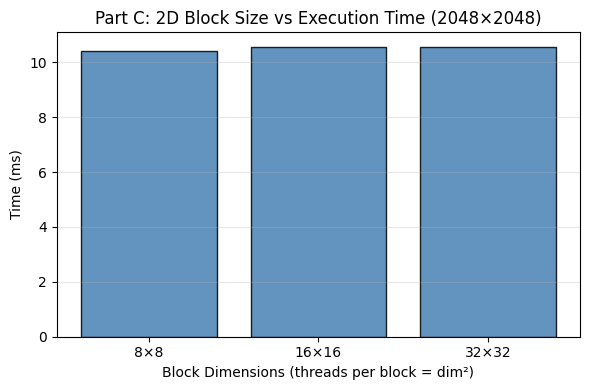

Plot saved: partC_blockdim.png


In [ ]:
# ── Part C: Block Dimension Sweep ─────────────────────────────────────────────
print('\n=== Part C: Block Dimension Sweep (2048×2048 matrix) ===')
N_fixed = 2048
A_f = np.random.randint(0, 100, (N_fixed, N_fixed), dtype=np.int32)
B_f = np.random.randint(0, 100, (N_fixed, N_fixed), dtype=np.int32)

block_dims = [8, 16, 32]   # block is (bd × bd)
bd_times   = []

for bd in block_dims:
    _, _ = cuda_matrix_add(A_f, B_f, block_dim=bd)  # warm-up
    _, ms = cuda_matrix_add(A_f, B_f, block_dim=bd)
    bd_times.append(ms)
    print(f'  Block {bd:>2}×{bd:<2} ({bd*bd:>4} threads/block) | {ms:.3f} ms')

plt.figure(figsize=(6, 4))
plt.bar([f'{b}×{b}' for b in block_dims], bd_times, color='steelblue', edgecolor='black', alpha=0.85)
plt.xlabel('Block Dimensions (threads per block = dim²)')
plt.ylabel('Time (ms)')
plt.title(f'Part C: 2D Block Size vs Execution Time ({N_fixed}×{N_fixed})')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('partC_blockdim.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: partC_blockdim.png')

---
## Summary

| Part | Task | Status |
|------|------|--------|
| A | Device Query + 10 Questions | ✅ |
| B | Array Sum (parallel reduction) + performance plots | ✅ |
| C | Matrix Addition + FLOPs/memory analysis + performance plots | ✅ |